# **Atividade Prática**
<font size=3>

- **Tema:** máquinas de vetores de suporte.

## **Enunciado:**
<font size=3>

Com base no *dataset* de [Doenças Cardíacas](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos para resolver a tarefa de classificação:

### **1º Passo:**
<font size=3>

- Importe o *dataset* e **imprima na tela** o dataframe;
- Transformer o atributo `AgeCategory` para que o intervalo das idades seja definida como a média, *e.g.*, $[20,\, 40] \rightarrow 30$;
- Defina a variável alvo como `HeartDisease` e as demais como a variável de atributos.


In [82]:
import pandas as pd

In [83]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/heart_disease.csv", encoding='latin-1')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,Yes,25.06,No,No,No,30.0,30.0,Yes,Female,60-64,White,Yes,No,Poor,10.0,No,No,No
1,No,24.39,No,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Excellent,8.0,No,No,No
2,No,33.91,Yes,Yes,No,30.0,30.0,No,Male,30-34,White,No,Yes,Poor,7.0,Yes,No,No
3,No,27.79,Yes,No,No,0.0,0.0,Yes,Female,55-59,White,No,Yes,Good,7.0,No,No,No
4,No,32.89,No,No,No,30.0,15.0,Yes,Female,75-79,White,Yes,Yes,Fair,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,No,28.04,No,No,No,2.0,1.0,Yes,Female,65-69,White,No,Yes,Good,8.0,No,No,Yes
2882,No,22.32,Yes,No,No,0.0,0.0,No,Male,30-34,White,No,Yes,Excellent,7.0,No,No,No
2883,No,23.71,No,No,No,0.0,0.0,No,Male,50-54,White,No,Yes,Very good,7.0,No,No,No
2884,No,29.76,Yes,No,No,4.0,4.0,No,Male,40-44,Hispanic,No,Yes,Good,8.0,No,No,No


In [84]:
import re
import numpy as np

# pegando coluna
AgeCategory = df["AgeCategory"].tolist()

nova_coluna = []

# loop: ler valores
for idade in AgeCategory:

    # extrair nums
    numeros = re.findall(r'\d+', str(idade))

    # converter para int
    numeros = [int(n) for n in numeros]

    media = int(np.mean(numeros))

    # adicionando na nova lista
    nova_coluna.append(media)

# substituindo coluna original
df["AgeCategory"] = nova_coluna
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,Yes,25.06,No,No,No,30.0,30.0,Yes,Female,62,White,Yes,No,Poor,10.0,No,No,No
1,No,24.39,No,No,No,0.0,0.0,No,Male,37,White,No,Yes,Excellent,8.0,No,No,No
2,No,33.91,Yes,Yes,No,30.0,30.0,No,Male,32,White,No,Yes,Poor,7.0,Yes,No,No
3,No,27.79,Yes,No,No,0.0,0.0,Yes,Female,57,White,No,Yes,Good,7.0,No,No,No
4,No,32.89,No,No,No,30.0,15.0,Yes,Female,77,White,Yes,Yes,Fair,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,No,28.04,No,No,No,2.0,1.0,Yes,Female,67,White,No,Yes,Good,8.0,No,No,Yes
2882,No,22.32,Yes,No,No,0.0,0.0,No,Male,32,White,No,Yes,Excellent,7.0,No,No,No
2883,No,23.71,No,No,No,0.0,0.0,No,Male,52,White,No,Yes,Very good,7.0,No,No,No
2884,No,29.76,Yes,No,No,4.0,4.0,No,Male,42,Hispanic,No,Yes,Good,8.0,No,No,No


In [85]:
# variável alvo
y = df["HeartDisease"]

# variáveis de atributos
X = df.drop(columns=["HeartDisease"])

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2886, 17)
Formato de y: (2886,)


### **2º Passo:**
<font size=3>

- Utilize a função `unique` do Numpy para identificar as proporções das classes da variável `y`;
- Realize a divisão dos dados entre treinamento e teste. Caso seja necessário, faça a estratificação;
- Utilize a classe [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar `y_train` e `y_test`;
- Para transformar os dados de atributos:
    - Defina o transformador ([`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)) dos dados categóricos;
    - Defina o transformador ([`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) dos dados numéricos.
- Defina o objeto preprocessador com a classe [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [87]:
from numpy import unique

# as classes e as quantidades
classes, counts = unique(y, return_counts=True)

print("Classes:", classes)
print("Quantidade:", counts)
print("Proporções:", counts / len(y))

Classes: ['No' 'Yes']
Quantidade: [2339  547]
Proporções: [0.81046431 0.18953569]


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [89]:
# para y
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print(f"Classes aprendidas pelo LabelEncoder: {le.classes_}")
print("Alvos de treino depois da codificação:", y_train[:10])

Classes aprendidas pelo LabelEncoder: ['No' 'Yes']
Alvos de treino depois da codificação: [0 0 1 0 0 0 0 0 0 1]


In [90]:
numerical_atributes =  X.select_dtypes(include=['int64', 'float64']).columns #numéricas
categorical_atributes = X.select_dtypes(include=['object']).columns #categóricas

numeric_transformer = StandardScaler() # normaliza os num
categorical_transformer = OneHotEncoder() # converte categorias em num - binário

# transformar dados
preprocessor = ColumnTransformer(transformers=[('numerico', numeric_transformer, numerical_atributes),
                                               ('categorico', categorical_transformer, categorical_atributes)],remainder='passthrough' )
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerico', StandardScaler(),
                                 Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'AgeCategory', 'SleepTime'], dtype='object')),
                                ('categorico', OneHotEncoder(),
                                 Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'Race',
       'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease',
       'SkinCancer'],
      dtype='object'))])

In [91]:
print("Atributos numéricos:", numerical_atributes)
print("Atributos categóricos:", categorical_atributes)

Atributos numéricos: Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'AgeCategory', 'SleepTime'], dtype='object')
Atributos categóricos: Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'Race',
       'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease',
       'SkinCancer'],
      dtype='object')


### **3º Passo:**
<font size=3>

- Defina o objeto de [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) para encadear o objeto preprocessador e o modelo de [máquina de vetores de suporte](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html);
- Para treinar o modelo, utilize a classe [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) considerando:
    - As funções kernels `linear`, `poly` e `rbf`, com seus principais hiperparâmetros;
    - 10 iterações na busca de hiperparâmetros;
    - 5 divisões para validação cruzada;
    - Métrica acurácia.
- **Imprima na tela** os melhores hiperparâmetros e valor de acurácia.    

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

pipe = Pipeline(steps=[('preprocessor', preprocessor),
                       ('model', SVC(
                           kernel='rbf',
                           random_state=42))])
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerico', StandardScaler(),
                                                  Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'AgeCategory', 'SleepTime'], dtype='object')),
                                                 ('categorico', OneHotEncoder(),
                                                  Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'Race',
       'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease',
       'SkinCancer'],
      dtype='object'))])),
                ('model', SVC(random_state=42))])

In [98]:
from sklearn.model_selection import RandomizedSearchCV

# hiperparâmetros
param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.01, 0.1, 1, 10, 100]
    },

    {
        "model__kernel": ["rbf"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01, 0.001]
    },

    {
        "model__kernel": ["poly"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__degree": [2, 3, 4, 5],
        "model__gamma": ["scale", "auto"]
    }
]

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,

    n_iter=10,          # 10 combinações aleatórias
    cv=5,               # validação cruzada
    scoring="accuracy", # métrica
    random_state=42,
    n_jobs=-1
)

# treinamento
random_search.fit(X_train, y_train)

# melhores hiperparâmetros
print("Melhores hiperparâmetros:")
print(random_search.best_params_)

# melhor acurácia
print(f"\nAcurácia: {random_search.best_score_:.4f}")

Melhores hiperparâmetros:
{'model__kernel': 'poly', 'model__gamma': 'scale', 'model__degree': 4, 'model__C': 1}

Acurácia: 0.8342


### **4º Passo:**
<font size=3>

- Realize as predições com os dados de teste;
- Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) e [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) para plotar a **matriz de confusão**;
- Utilize a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para **imprimir na tela** os resultados da classificação;
- **Escreva** em uma **célula _markdown_** sua interpretação dos resultados.

In [94]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [95]:
# predições
y_pred = random_search.predict(X_test)

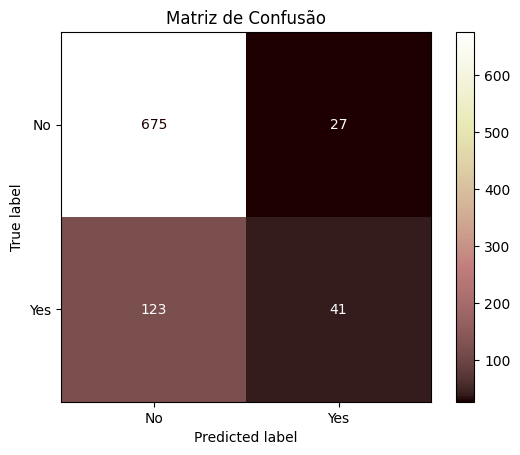

In [96]:
# matriz de confusão
matriz_c = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=matriz_c,
    display_labels=le.classes_
)

display.plot(cmap='pink')

plt.title("Matriz de Confusão")
plt.show()

In [97]:
# classificação
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

          No       0.85      0.96      0.90       702
         Yes       0.60      0.25      0.35       164

    accuracy                           0.83       866
   macro avg       0.72      0.61      0.63       866
weighted avg       0.80      0.83      0.80       866



Os resultados da classificação mostram o desempenho do modelo SVM na predição de doenças cardíacas. A matriz de confusão apresenta a quantidade de classificações corretas e incorretas feitas pelo modelo para as classes: Yes e No. Valores maiores na diagonal principal mostram que o modelo conseguiu classificar bem a maioria dos pacientes.

Sendo assim, erros nesse tipo de problema podem ter consequências sérias. Por exemplo, um falso negativo ocorre quando o modelo diz que o paciente não possui doença cardíaca, mesmo quando ele realmente possui. Na vida real, isso pode atrasar diagnósticos e tratamentos importantes. Já os falsos positivos também podem gerar preocupação desnecessária para o indivíduo.

Além disso, o modelo apresentou bons resultados de classificação, mas ainda não pode ser considerado totalmente confiável para uso real na área da saúde, uma vez que prever doenças cardíacas é um problema muito mais complexo do que os dados conseguem representar. O modelo utiliza apenas algumas características gerais dos pacientes, como idade, hábitos de saúde, sono e doenças prévias, enquanto na prática médica existem muitos outros fatores importantes, como exames clínicos, histórico familiar, genética, uso de medicamentos e condições específicas de cada pessoa.